# 🏆 10. Grayscale Average (AVG) Testing SVM (Loaded from Single .keras Container)

Notebook ini mengevaluasi kinerja SVM Classifier pada fitur testing CIFAR-10.
StandardScaler dan Model SVM dimuat **langsung dari file model tunggal .keras** (custom_cnn_cifar10_final.keras) via dataset HDF5 (/scaler_pickle & /svm_model_pickle) tanpa perlu training ulang.


In [1]:
import os
import sys

# Setup CUDA DLL path sebelum import TensorFlow agar cuDNN terdeteksi sempurna
_cuda_bin = r'C:\Users\daffa\anaconda3\envs\CNNgpu\Library\bin'
if os.path.exists(_cuda_bin):
    if _cuda_bin not in os.environ.get('PATH', ''):
        os.environ['PATH'] = _cuda_bin + ';' + os.environ.get('PATH', '')
    if hasattr(os, 'add_dll_directory'):
        try:
            os.add_dll_directory(_cuda_bin)
        except Exception:
            pass

import json
import h5py
import pickle
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

ARTIFACT_DIR = 'cifar10_artifacts/grayscale_avg'
final_keras_path = os.path.join(ARTIFACT_DIR, 'custom_cnn_cifar10_final.keras')

def load_injected_final_model(artifact_path):
    if not os.path.exists(artifact_path):
        raise FileNotFoundError(f"File model {artifact_path} tidak ditemukan!")
    cnn_model = tf.keras.models.load_model(artifact_path)
    with h5py.File(artifact_path, 'r') as h5f:
        if 'scaler_pickle' in h5f and 'svm_model_pickle' in h5f:
            scaler_bytes = bytes(h5f['scaler_pickle'][()])
            svm_bytes = bytes(h5f['svm_model_pickle'][()])
            scaler = pickle.loads(scaler_bytes)
            svm_model = pickle.loads(svm_bytes)
        elif 'svm_pipeline_pickle' in h5f:
            pipe_bytes = bytes(h5f['svm_pipeline_pickle'][()])
            pipe_obj = pickle.loads(pipe_bytes)
            if hasattr(pipe_obj, 'named_steps'):
                scaler = pipe_obj.named_steps.get('scaler', None)
                svm_model = pipe_obj.named_steps.get('svm', pipe_obj)
            else:
                scaler = None
                svm_model = pipe_obj
        else:
            raise KeyError(f"Dataset Scaler/SVM tidak ditemukan dalam {artifact_path}!")
        metadata = {}
        for k, v in h5f.attrs.items():
            if isinstance(v, bytes):
                metadata[k] = v.decode('utf-8')
            else:
                metadata[k] = v
    return cnn_model, scaler, svm_model, metadata


def evaluate_classification(y_true, y_pred, title='Model Evaluation', plot_cm=True, save_cm_path=None):
    acc = accuracy_score(y_true, y_pred)
    prec_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    prec_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print('=================================================================')
    print(f'  {title.upper()}')
    print('=================================================================')
    print(f'  Accuracy           : {acc * 100:.2f}% ({acc:.4f})')
    print(f'  Precision (Macro)  : {prec_macro * 100:.2f}% ({prec_macro:.4f})')
    print(f'  Recall (Macro)     : {rec_macro * 100:.2f}% ({rec_macro:.4f})')
    print(f'  F1-Score (Macro)   : {f1_macro * 100:.2f}% ({f1_macro:.4f})')
    print('-----------------------------------------------------------------')
    print(f'  Precision (Weight) : {prec_weighted * 100:.2f}% ({prec_weighted:.4f})')
    print(f'  Recall (Weight)    : {rec_weighted * 100:.2f}% ({rec_weighted:.4f})')
    print(f'  F1-Score (Weight)  : {f1_weighted * 100:.2f}% ({f1_weighted:.4f})')
    print('=================================================================')
    print('\n--- CLASSIFICATION REPORT ---')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    if plot_cm:
        plt.figure(figsize=(9, 7))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
        plt.title(f'Confusion Matrix: {title}', fontsize=14, fontweight='bold')
        plt.xlabel('Predicted Label', fontsize=12)
        plt.ylabel('True Label', fontsize=12)
        plt.tight_layout()
        if save_cm_path:
            os.makedirs(os.path.dirname(save_cm_path), exist_ok=True)
            plt.savefig(save_cm_path, dpi=200)
            print(f'[INFO] Confusion Matrix heatmap disimpan ke: {save_cm_path}')
        plt.show()

    return {
        'accuracy': float(acc),
        'precision_macro': float(prec_macro),
        'recall_macro': float(rec_macro),
        'f1_macro': float(f1_macro),
        'precision_weighted': float(prec_weighted),
        'recall_weighted': float(rec_weighted),
        'f1_weighted': float(f1_weighted),
        'confusion_matrix': cm.tolist()
    }

print(f"Memuat model dari SATU file .keras: {final_keras_path}")
cnn_model, scaler, svm_model, metadata = load_injected_final_model(final_keras_path)
print(f"[BERHASIL] Scaler dan SVM Model berhasil dimuat dari file .keras!")
print("Metadata:", metadata)

Memuat model dari SATU file .keras: cifar10_artifacts/grayscale_avg\custom_cnn_cifar10_final.keras
[BERHASIL] Scaler dan SVM Model berhasil dimuat dari file .keras!
Metadata: {'backend': 'tensorflow', 'feature': 'Grayscale AVG', 'feature_dim': 512, 'keras_version': '2.10.0', 'method': 'Grayscale Average (AVG) CNN + SVM', 'model_config': '{"class_name": "Functional", "config": {"name": "custom_cnn", "layers": [{"class_name": "InputLayer", "config": {"batch_input_shape": [null, 32, 32, 1], "dtype": "float32", "sparse": false, "ragged": false, "name": "input_image"}, "name": "input_image", "inbound_nodes": []}, {"class_name": "Conv2D", "config": {"name": "conv1_1", "trainable": true, "dtype": "float32", "filters": 64, "kernel_size": [3, 3], "strides": [1, 1], "padding": "same", "data_format": "channels_last", "dilation_rate": [1, 1], "groups": 1, "activation": "relu", "use_bias": true, "kernel_initializer": {"class_name": "GlorotUniform", "config": {"seed": null}}, "bias_initializer": {"c

## 📥 1. Memuat Vektor Fitur Testing, Transformasi Scaler & Inferensi SVM


In [2]:
test_feat_path = os.path.join(ARTIFACT_DIR, 'test_features.npz')
test_data = np.load(test_feat_path)
X_test_features = test_data['X_test_features']
y_test = test_data['y_test']

print("1. Menstandarisasi vektor fitur testing menggunakan scaler training...")
if scaler is not None:
    X_test_scaled = scaler.transform(X_test_features)
else:
    X_test_scaled = X_test_features
print(f"Bentuk fitur testing terskala: {X_test_scaled.shape}")

print()
print("2. Menjalankan prediksi SVM pada seluruh test set (10.000 sampel)...")
y_pred_svm = svm_model.predict(X_test_scaled)

1. Menstandarisasi vektor fitur testing menggunakan scaler training...
Bentuk fitur testing terskala: (10000, 512)

2. Menjalankan prediksi SVM pada seluruh test set (10.000 sampel)...


## 📊 2. Classification Report & Confusion Matrix (SVM)


  GRAYSCALE AVERAGE (AVG) CNN + SVM EVALUATION
  Accuracy           : 88.99% (0.8899)
  Precision (Macro)  : 89.01% (0.8901)
  Recall (Macro)     : 88.99% (0.8899)
  F1-Score (Macro)   : 88.99% (0.8899)
-----------------------------------------------------------------
  Precision (Weight) : 89.01% (0.8901)
  Recall (Weight)    : 88.99% (0.8899)
  F1-Score (Weight)  : 88.99% (0.8899)

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

    airplane     0.9060    0.9060    0.9060      1000
  automobile     0.9430    0.9590    0.9509      1000
        bird     0.8365    0.8490    0.8427      1000
         cat     0.7630    0.7760    0.7695      1000
        deer     0.8673    0.8760    0.8716      1000
         dog     0.8439    0.8110    0.8271      1000
        frog     0.9064    0.9200    0.9132      1000
       horse     0.9399    0.9230    0.9314      1000
        ship     0.9470    0.9470    0.9470      1000
       truck     0.9481    0.9320    0.940

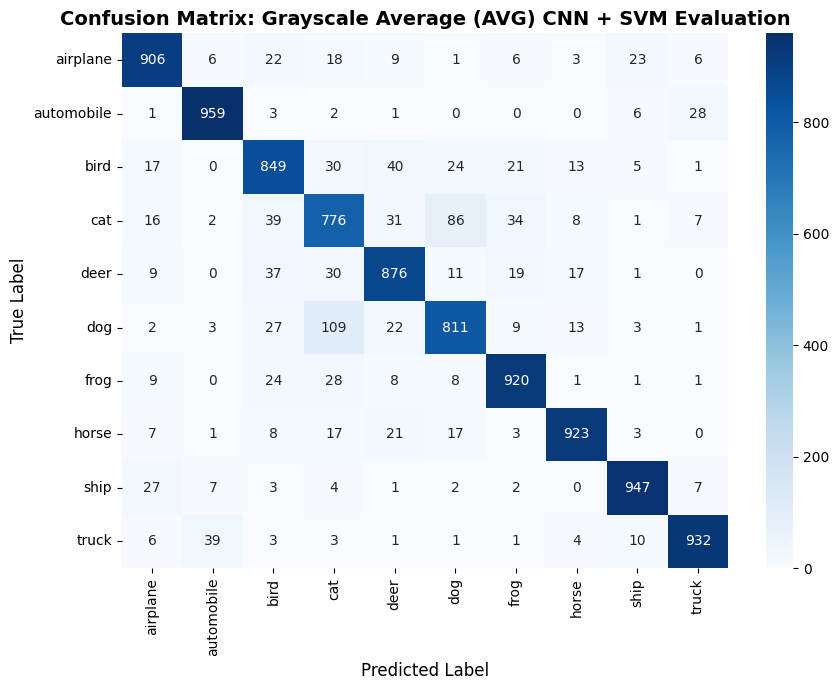


[FINAL RESULT] Grayscale AVG CNN + SVM Test Accuracy: 88.99%
[FINAL RESULT] Grayscale AVG CNN + SVM F1-Score (Macro): 88.99%


In [3]:
cm_path = os.path.join(ARTIFACT_DIR, 'confusion_matrix_svm.png')
metrics_svm = evaluate_classification(
    y_true=y_test,
    y_pred=y_pred_svm,
    title="Grayscale Average (AVG) CNN + SVM Evaluation",
    plot_cm=True,
    save_cm_path=cm_path
)

with open(os.path.join(ARTIFACT_DIR, 'metrics_svm.json'), 'w') as f:
    json.dump(metrics_svm, f, indent=2)

print()
print(f"[FINAL RESULT] Grayscale AVG CNN + SVM Test Accuracy: {metrics_svm['accuracy'] * 100:.2f}%")
print(f"[FINAL RESULT] Grayscale AVG CNN + SVM F1-Score (Macro): {metrics_svm['f1_macro'] * 100:.2f}%")
